In [1]:

import numpy as np
import matplotlib.pyplot as plt 
from matplotlib.colors import ListedColormap, BoundaryNorm
import time

# from spin_sampler import Sampler , define_hopfield_model , initialize_spins
from configurations import load_data, make_params_dict, set_font_sizes, create_fig , apply_general_styles, save_fig
from configurations.plots import FONTSIZES

apply_general_styles()

# N scaling of BID/N vs T

In [10]:
# Get data from cluster --> later

In [28]:
# Parse arguments
a_min = 1e-3
a_max = 0.3
z_threshold = 3
kl_perc = 80 

# Parameters fixed
N_samples = 10000
dt_samples = 1
burnin = 800
alpha = 0.04
h = 0.9
rnd_ord = True
mode = 'single_chain'

# Parameters Lists
temps = np.linspace(0.4,1.6,25)
temps = np.concatenate((temps, [0.56,1.19, 1.21]))
temps = np.sort(temps)
temps = temps[temps>=1.1]
# temps = temps[temps<=1.5]
Ns = np.logspace(9,15,7,base=2).astype(int)[1:-1]

# Parameters to save
names_variable = ['T','N']
name_fixed = ['N_samples','dt_samples','burnin','alpha','h','rnd_ord','mode','a_min','a_max','z_threshold','kl_perc']


results = {
    N: {'av': [],'st':[] }  for N in Ns
    }

data = []
for N in Ns:
    for T in temps:
        params = make_params_dict(name_fixed,names_variable)
        # print('-----------\n',f'Loading N={N}, T={T}...')
        dic = load_data('par',experiment_name= 'scaling_exponents_filtered', params=params,base_dir='..\\data',show=False)
        # print(dic['sigmas'].shape)
        # bid = dic['bid_pars'][:,0]
        bid = dic['sigmas']**2 * N
        data.append([N,T,bid.mean(),bid.std()])
        results[N]['av'].append(bid.mean())
        results[N]['st'].append(bid.std())
    results[N]['av'] = np.array(results[N]['av'])
    results[N]['st'] = np.array(results[N]['st'])
data = np.array(data)
print(data.shape)

np.savetxt('../data/fss/var.dat',data)

(65, 4)


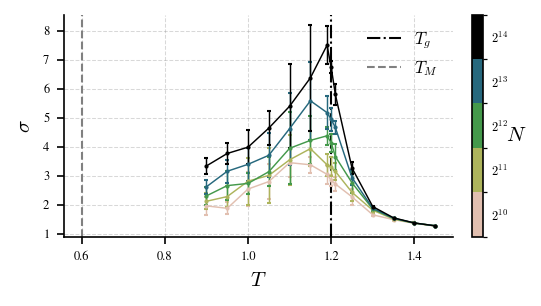

In [9]:
# Settings

cmap = 'gist_earth_r'
colors = plt.get_cmap(cmap)(np.linspace(0.1,1,len(Ns)))
set_font_sizes(conf='tight')
Nlbs = [rf'$2^{{{int(np.log2(N))}}}$' for N in Ns]


# Plotting
fig , axes = create_fig(h=0.55,w=1.0)
ax = axes

ax.axvline(1.2,color='black',ls='-.',lw=1,label=r'$T_g$')
ax.axvline(0.6,color='gray',ls='--',lw=1,label=r'$T_M$')
for i , N in enumerate(Ns):
    # ax.plot(temps, results[N]['av'], label=f'N={N}', marker='.',markersize=2,lw=0.7,color=colors[i])
    ax.errorbar(temps, results[N]['av'], yerr=results[N]['st'], marker='.',markersize=2,lw=0.7, capsize=1,color=colors[i])

ax.grid(True, which='both', ls='--', lw=0.5,color='gray', alpha=0.3)
ax.set_xlabel(r'$T$')
# ax.set_ylabel(r'$BID / N$')
ax.set_ylabel(r'$\sigma$')
ax.legend(frameon=False,fontsize=FONTSIZES['s'])

# Create discrete colormap and colorbar with discrete colors
cmap = ListedColormap(colors)
bounds = np.arange(len(Ns) + 1)
norm = BoundaryNorm(bounds, cmap.N)

cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap=cmap,norm=norm),
    ax=ax, orientation='vertical')#,pad=0.05)

cbar.set_label(r'$N$', rotation=0)#, labelpad=10)
# Ticks and labels
cbar.set_ticks(ticks=(np.arange(len(Ns)) + 0.5), labels= Nlbs)
cbar.ax.tick_params(length=0)  # Optional: remove tick lines for clarity


names = ['N_samples','alpha','h','mode','a_min','a_max','z_threshold','kl_perc']
params = make_params_dict(names)
# save_fig(fig, 'BID_vs_T_scaling',params=params)

# Graph collapse


In [32]:
# Parse arguments
a_min = 1e-3
a_max = 0.3
z_threshold = 3
kl_perc = 80 

# Parameters fixed
N_samples = 10000
dt_samples = 1
burnin = 800
alpha = 0.04
h = 0.9
rnd_ord = True
mode = 'single_chain'

# Parameters Lists
temps = np.linspace(0.4,1.6,25)
temps = np.concatenate((temps, [0.56,1.19, 1.21]))
temps = np.sort(temps)
temps = temps[temps>=0.8]
temps = temps[temps<=1.4]
Ns = np.logspace(9,15,7,base=2).astype(int)[1:-1]

# Parameters to save
names_variable = ['T','N']
name_fixed = ['N_samples','dt_samples','burnin','alpha','h','rnd_ord','mode','a_min','a_max','z_threshold','kl_perc']


results = {
    N: {'av': [],'st':[] }  for N in Ns
    }

for N in Ns:
    for T in temps:
        params = make_params_dict(name_fixed,names_variable)
        # print('-----------\n',f'Loading N={N}, T={T}...')
        dic = load_data('par',experiment_name= 'scaling_exponents_filtered', params=params,base_dir='..\\data',show=False)
        bid = dic['bid_pars'][:,0]
        # bid = dic['sigmas']**2 * N
        
        results[N]['av'].append(bid.mean())
        results[N]['st'].append(bid.std())
    results[N]['av'] = np.array(results[N]['av'])
    results[N]['st'] = np.array(results[N]['st'])

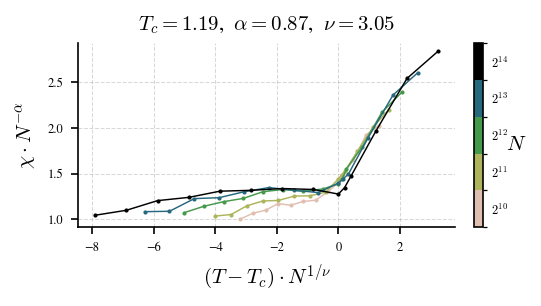

In [49]:
# Settings
# Retulst BID
# Tc = 1.218016505241394
# c1 = 0.34914830327033997
# c2 = -0.9545260667800903
# # Results CHI
# Tc = 1.2179301977157593
Tc = 1.19
c1 = 0.41859498620033264
c2 = -0.2485182136297226
# alpha = -c2
# nu = 1/c1
nu = 3.05
alpha = 0.87


cmap = 'gist_earth_r'
colors = plt.get_cmap(cmap)(np.linspace(0.1,1,len(Ns)))
set_font_sizes(conf='tight')
Nlbs = [rf'$2^{{{int(np.log2(N))}}}$' for N in Ns]


# Plotting
fig , axes = create_fig(h=0.55,w=1.0)
ax = axes

for i , N in enumerate(Ns):
    bid = results[N]['av']
    x = bid*N**-alpha
    t = (temps - Tc)/Tc *N**(1/nu)
    ax.plot(t, x, marker='.',markersize=2,lw=0.7,color=colors[i])
    errx = results[N]['st']*N**-alpha
    # ax.errorbar(t, x,yerr=errx, marker='.',markersize=2,lw=0.7, capsize=1,color=colors[i])

ax.grid(True, which='both', ls='--', lw=0.5,color='gray', alpha=0.3)
ax.set_xlabel(r'$(T-T_c) \cdot N^{1/\nu}$')
ax.set_ylabel(r'$\chi \cdot N^{-\alpha}$')

# ax.legend(frameon=False,fontsize=FONTSIZES['s'])

# Create discrete colormap and colorbar with discrete colors
cmap = ListedColormap(colors)
bounds = np.arange(len(Ns) + 1)
norm = BoundaryNorm(bounds, cmap.N)

cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap=cmap,norm=norm),
    ax=ax, orientation='vertical')#,pad=0.05)

cbar.set_label(r'$N$', rotation=0)#, labelpad=10)
# Ticks and labels
cbar.set_ticks(ticks=(np.arange(len(Ns)) + 0.5), labels= Nlbs)
cbar.ax.tick_params(length=0)  # Optional: remove tick lines for clarity

ax.set_title(rf'$T_c = {Tc:.3}$,  $\alpha={alpha:.3}$,  $\nu={nu:.3}$')

# ax.set_xlim(-5,5)
# ax.set_ylim(0.5,4)
names = ['N_samples','alpha','h','mode','a_min','a_max','z_threshold','kl_perc']
params = make_params_dict(names)
# save_fig(fig, 'bid_vs_T_scaling',params=params)